<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

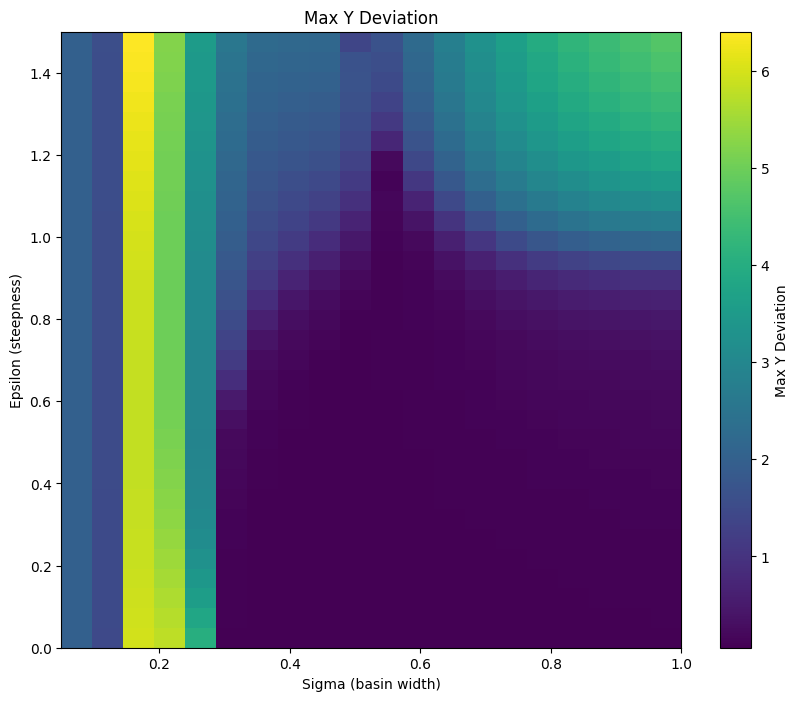

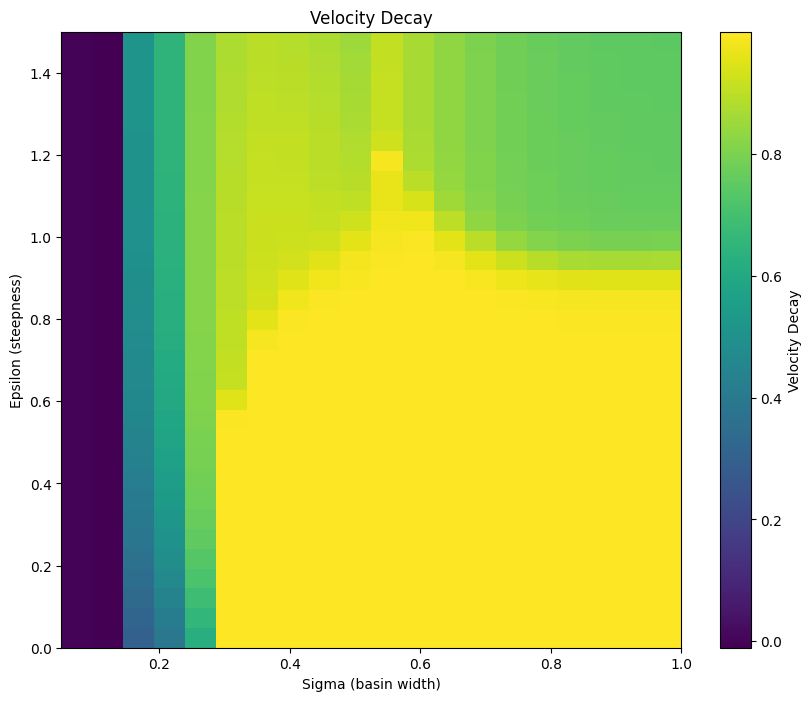

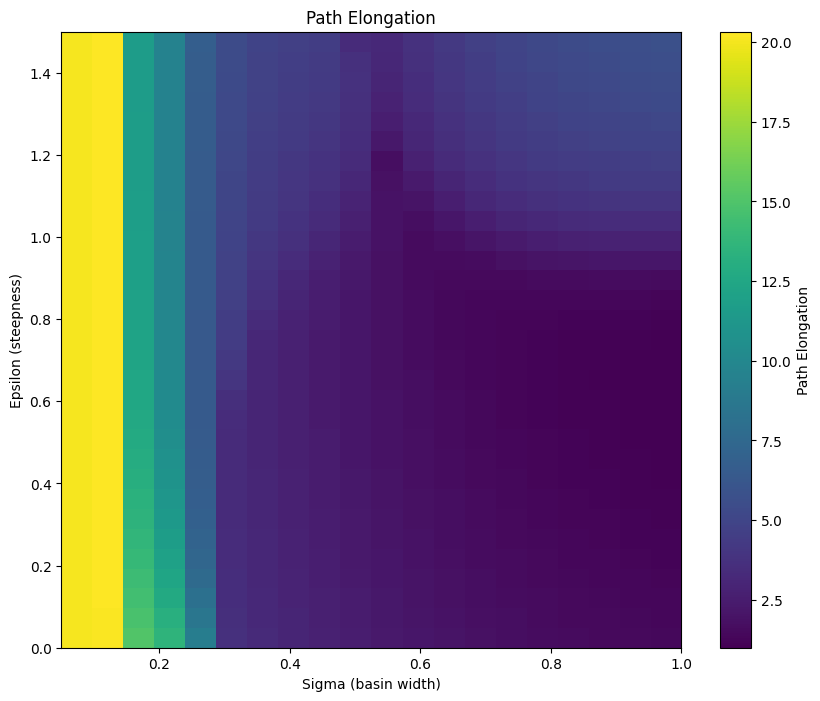

In [ ]:
# 🧬 TEG010: Horizon Basin Mapping
# Full curvature sweep across epsilon and sigma
# Author: Chris & Copilot | Arc VIII: Tensorial Emergence

import numpy as np
import matplotlib.pyplot as plt

# 📐 Curvature Tensor
def curvature_tensor(x, y, sigma, epsilon, stretch):
    x_scaled = x / stretch
    exp_term = np.exp(-(x_scaled**2 + y**2) / (2 * sigma**2))
    Cxx = (1 - x_scaled**2 / sigma**2) * exp_term * (1 + epsilon)
    Cyy = (1 - y**2 / sigma**2) * exp_term * (1 - epsilon)
    Cxy = (-x_scaled * y / sigma**2) * exp_term
    return np.array([[Cxx, Cxy], [Cxy, Cyy]])

# 🧲 Tensor Force
def tensor_force(x, y, vx, vy, sigma, epsilon, stretch):
    C = curvature_tensor(x, y, sigma, epsilon, stretch)
    v = np.array([vx, vy])
    f = -np.dot(C, v)
    return f[0], f[1]

# 🚀 Simulation Loop
def simulate_trajectory(x0, y0, vx0, vy0, sigma, epsilon, stretch, steps=2000, dt=0.01):
    x, y = x0, y0
    vx, vy = vx0, vy0
    trajectory = []

    for _ in range(steps):
        fx, fy = tensor_force(x, y, vx, vy, sigma, epsilon, stretch)
        vx += fx * dt
        vy += fy * dt
        x += vx * dt
        y += vy * dt
        trajectory.append((x, y, vx, vy))

    return np.array(trajectory)

# 📊 Metrics
def compute_metrics(traj):
    x_vals, y_vals = traj[:,0], traj[:,1]
    vx_vals, vy_vals = traj[:,2], traj[:,3]
    deviation = np.max(np.abs(y_vals))
    velocity_decay = 1.0 - np.linalg.norm([vx_vals[-1], vy_vals[-1]]) / np.linalg.norm([vx_vals[0], vy_vals[0]])
    path_length = np.sum(np.sqrt(np.diff(x_vals)**2 + np.diff(y_vals)**2))
    return deviation, velocity_decay, path_length

# 🔁 Parameter Sweep
epsilons = np.arange(0.0, 1.55, 0.05)
sigmas = np.arange(0.05, 1.05, 0.05)
stretch = 5.0

deviation_map = np.zeros((len(epsilons), len(sigmas)))
velocity_decay_map = np.zeros((len(epsilons), len(sigmas)))
elongation_map = np.zeros((len(epsilons), len(sigmas)))

for i, epsilon in enumerate(epsilons):
    for j, sigma in enumerate(sigmas):
        traj = simulate_trajectory(-3.0, 0.0, 1.0, 0.1, sigma, epsilon, stretch)
        deviation, decay, elongation = compute_metrics(traj)
        deviation_map[i, j] = deviation
        velocity_decay_map[i, j] = decay
        elongation_map[i, j] = elongation

# 📊 Plot Heatmaps
def plot_heatmap(data, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(data, origin='lower', aspect='auto',
               extent=[sigmas[0], sigmas[-1], epsilons[0], epsilons[-1]],
               cmap='viridis')
    plt.colorbar(label=title)
    plt.xlabel("Sigma (basin width)")
    plt.ylabel("Epsilon (steepness)")
    plt.title(title)
    plt.grid(False)
    plt.show()

plot_heatmap(deviation_map, "Max Y Deviation")
plot_heatmap(velocity_decay_map, "Velocity Decay")
plot_heatmap(elongation_map, "Path Elongation")
